In [1]:
'''
Paper: Learning and Control using Gaussian Processes
Source:
- https://github.com/mlab-upenn/ICCPS18_DPC_GP/blob/master/code/dependencies/learn_gp_hyperparameters_doe.m
- https://github.com/rmgarnett/mgp/tree/master
- https://github.com/rmgarnett/active_gp_hyperlearning/blob/master/select_next_point.m
'''

'\nPaper: Learning and Control using Gaussian Processes\nSource:\n- https://github.com/mlab-upenn/ICCPS18_DPC_GP/blob/master/code/dependencies/learn_gp_hyperparameters_doe.m\n- https://github.com/rmgarnett/mgp/tree/master\n- https://github.com/rmgarnett/active_gp_hyperlearning/blob/master/select_next_point.m\n'

In [2]:
import requests
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import gpytorch
from common import get_data, to_tensor
import constant as const
from call_GP import train_GP, ExactGPModel, evaluate_gp, call_model, cal_pos

url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

print("done")

Using: cuda
done


In [3]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

version = requests.get('{0}/version'.format(url)).json()['payload']
print(version)
inputs = requests.get('{0}/inputs/{1}'.format(url, testid)).json()['payload']
print('TEST CASE INPUTS ---------------------------------------------')
print(inputs.keys())

print('TEST CASE MEASUREMENTS ---------------------------------------')
measurements = requests.get('{0}/measurements/{1}'.format(url, testid)).json()['payload']

{'name': 'bestest_air'}
{'version': '0.8.0'}
TEST CASE INPUTS ---------------------------------------------
dict_keys(['con_oveTSetCoo_activate', 'con_oveTSetCoo_u', 'con_oveTSetHea_activate', 'con_oveTSetHea_u', 'fcu_oveFan_activate', 'fcu_oveFan_u', 'fcu_oveTSup_activate', 'fcu_oveTSup_u'])
TEST CASE MEASUREMENTS ---------------------------------------


In [4]:
step = const.step

data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data_test = data

data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0


pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]


def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))


Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 
cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  
X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

ramp = const.ramp

In [ ]:
class MPC:
    def __init__(self, X_tr, y_tr, model_path=f'model_AL_SE_GP_{step}m.pth'):
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        self.model = ExactGPModel(X_tr, y_tr, self.likelihood).to(device)
        state_dict = torch.load(model_path, map_location=device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        self.X_tr = X_tr
        self.y_tr = y_tr

    def _build_sigma(self, prior_precision=1.0):
        params = [
            self.model.covar_module.base_kernel.raw_lengthscale,
            self.model.covar_module.raw_outputscale,
            self.likelihood.raw_noise
        ]
        n_params = sum(p.numel() for p in params)

        self.model.train()
        self.likelihood.train()

        output = self.model(self.X_tr)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)
        loss = -mll(output, self.y_tr) * self.X_tr.shape[0]

        param_vec = torch.cat([p.reshape(-1) for p in params])
        loss = loss + 0.5 * prior_precision * (param_vec ** 2).sum()

        grads = torch.autograd.grad(loss, params, create_graph=True)
        grad_flat = torch.cat([g.reshape(-1) for g in grads])

        H = torch.zeros(n_params, n_params, device=grad_flat.device)
        for i in range(n_params):
            Hi = torch.autograd.grad(grad_flat[i], params, retain_graph=True, allow_unused=True)
            Hi_flat = torch.cat([h.reshape(-1) if h is not None else torch.zeros_like(p).reshape(-1)
                                 for h, p in zip(Hi, params)])
            H[i] = Hi_flat

        Sigma = torch.linalg.inv(H + 1e-4 * torch.eye(n_params, device=H.device))
        self.model.eval()
        self.likelihood.eval()
        return params, n_params, Sigma

    def _SE_scores(self, Z, params, n_params, Sigma):
        N = Z.shape[0]
        with torch.enable_grad(), gpytorch.settings.fast_pred_var(False):
            posterior = self.model(Z)
            mu  = posterior.mean
            var = posterior.variance.clamp_min(1e-3)

        J_mu  = torch.zeros(N, n_params, device=Z.device)
        J_var = torch.zeros(N, n_params, device=Z.device)
        for i in range(N):
            gm = torch.autograd.grad(mu[i],  params, retain_graph=True, allow_unused=True)
            J_mu[i]  = torch.cat([g.reshape(-1) if g is not None else torch.zeros_like(p).reshape(-1)
                                   for g, p in zip(gm, params)])
            gv = torch.autograd.grad(var[i], params, retain_graph=(i < N - 1), allow_unused=True)
            J_var[i] = torch.cat([g.reshape(-1) if g is not None else torch.zeros_like(p).reshape(-1)
                                   for g, p in zip(gv, params)])

        term_mu  = torch.einsum('ni,ij,nj->n', J_mu,  Sigma, J_mu)
        term_var = torch.einsum('ni,ij,nj->n', J_var, Sigma, J_var) / (3 * var)
        mgp_var  = (4.0 / 3.0) * var + term_mu + term_var
        return (mgp_var / var).detach().cpu().numpy()

    def mpc_grid_search(self, x0, x_out, horizon=1, n_grid=5, u0_1=0.5, u0_2=0.5, plot=True):
        x0 = float(x0 / 30.0)

        u_min_general = np.array([0.3, 0.])
        u_max_general = np.array([1.0, 1.0])
        u_min = np.clip(np.array([u0_1 - ramp, u0_2 - ramp]), u_min_general, u_max_general)
        u_max = np.clip(np.array([u0_1 + ramp, u0_2 + ramp]), u_min_general, u_max_general)

        u1_vals = np.linspace(u_min[0], u_max[0], n_grid)
        u2_vals = np.linspace(u_min[1], u_max[1], n_grid)

        U1, U2 = np.meshgrid(u1_vals, u2_vals, indexing='ij')
        U1f, U2f = U1.ravel(), U2.ravel()
        N = n_grid * n_grid
        Z = torch.tensor(
            np.stack([np.full(N, x0), U1f, U2f, np.full(N, x_out)], axis=1),
            device=device, dtype=torch.float32
        )

        params, n_params, Sigma = self._build_sigma()
        scores = self._SE_scores(Z, params, n_params, Sigma)
        cost_grid = scores.reshape(n_grid, n_grid)

        skip = (U1f == u0_1) | (U2f == u0_2)
        scores_masked = scores.copy()
        scores_masked[skip] = -np.inf
        best_idx = np.argmax(scores_masked)
        best_u = np.array([U1f[best_idx], U2f[best_idx]])

        if plot:
            plt.figure(figsize=(6, 5))
            cp = plt.contourf(U1, U2, cost_grid, levels=30, cmap="viridis")
            plt.colorbar(cp, label="Cost (-variance)")
            plt.scatter(best_u[0], best_u[1], c="red", marker="x", s=100)
            plt.xlabel("u1 (supply)")
            plt.ylabel("u2 (airflow)")
            plt.title("Grid Search Cost Landscape")
            plt.show()

        u = {
            'fcu_oveTSup_u': best_u[0] * 40 + 273.15,
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u': best_u[1],
            'fcu_oveFan_activate': 1
        }
        return u

In [ ]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':step*60})
start_time_days = y['time']/3600/24
train_GP(X_tr=X_tr, y_tr=y_tr, save_path=f'model_AL_SE_GP_{step}m.pth', ori=0)

In [ ]:
last_change_day = start_time_days
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {
        'fcu_oveTSup_u': u0_1 * 40 + 273.15,
        'fcu_oveTSup_activate': 1,
        'fcu_oveFan_u': u0_2,
        'fcu_oveFan_activate': 1
        }

x_ref = 25
simulation_time_days = y['time']/3600/24
print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  


ls_rmse = [evaluate_gp(X_tr, y_tr, X_t, y_t, save_path=f'model_AL_SE_GP_{step}m.pth')]
X_tr_new = X_tr
y_tr_new = y_tr
num_count = const.num_count

Simulation time [elapsed days] = 0.00


In [ ]:
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    x_out = (y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0
    mpc_controller = MPC(X_tr_new, y_tr_new, model_path=f'model_AL_SE_GP_{step}m.pth')
    u = mpc_controller.mpc_grid_search(x0=x0, x_out=x_out, horizon=1, u0_1=u0_1, u0_2=u0_2, n_grid=5, plot =False)

    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    print("Controller output:", u)

    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    counter += 1


    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add=  to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0

    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)

    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)

    y_tr_n = pos_add.squeeze(-1)   
    
    X_tr_new = torch.cat([X_tr_new, X_tr_n], dim=0)
    y_tr_new = torch.cat([y_tr_new, y_tr_n], dim=0)

    if const.count_data == const.number_of_data:
        train_GP(X_tr=X_tr_new, y_tr=y_tr_new, save_path=f'model_AL_SE_GP_{step}m.pth', ori=1)
        print("=============================== Retrained the GP model ==============================")
        const.count_data = 0
    const.count_data += 1
    simulation_time_days = y['time']/3600/24
    print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))

    u0_1 = (u['fcu_oveTSup_u']-273.15)/40.0
    u0_2 = u['fcu_oveFan_u']

    rmse = evaluate_gp(X_tr_new, y_tr_new, X_t, y_t, save_path=f'model_AL_SE_GP_{step}m.pth')

    ls_rmse.append(rmse)
    if counter > num_count:
        break

-------------------------------------------------------------------
Step counter = 0
Controller output: {'fcu_oveTSup_u': np.float64(297.15), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.39999999999999997), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 1
Controller output: {'fcu_oveTSup_u': np.float64(293.15), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.29999999999999993), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 2
Controller output: {'fcu_oveTSup_u': np.float64(297.15), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.39999999999999997), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 3
Controller output: {'fcu_oveTSup_u': np.float64(293.15), 'fcu_oveTSup

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
C:\Users\namng\AppData\Local\Temp\ipykernel_40524\137404845.py:33: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
C:\Users\namng\AppData\Local\Temp\ipykernel_40524\137404845.py:39: SyntaxWarning: invalid escape sequence '\c'
  axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')


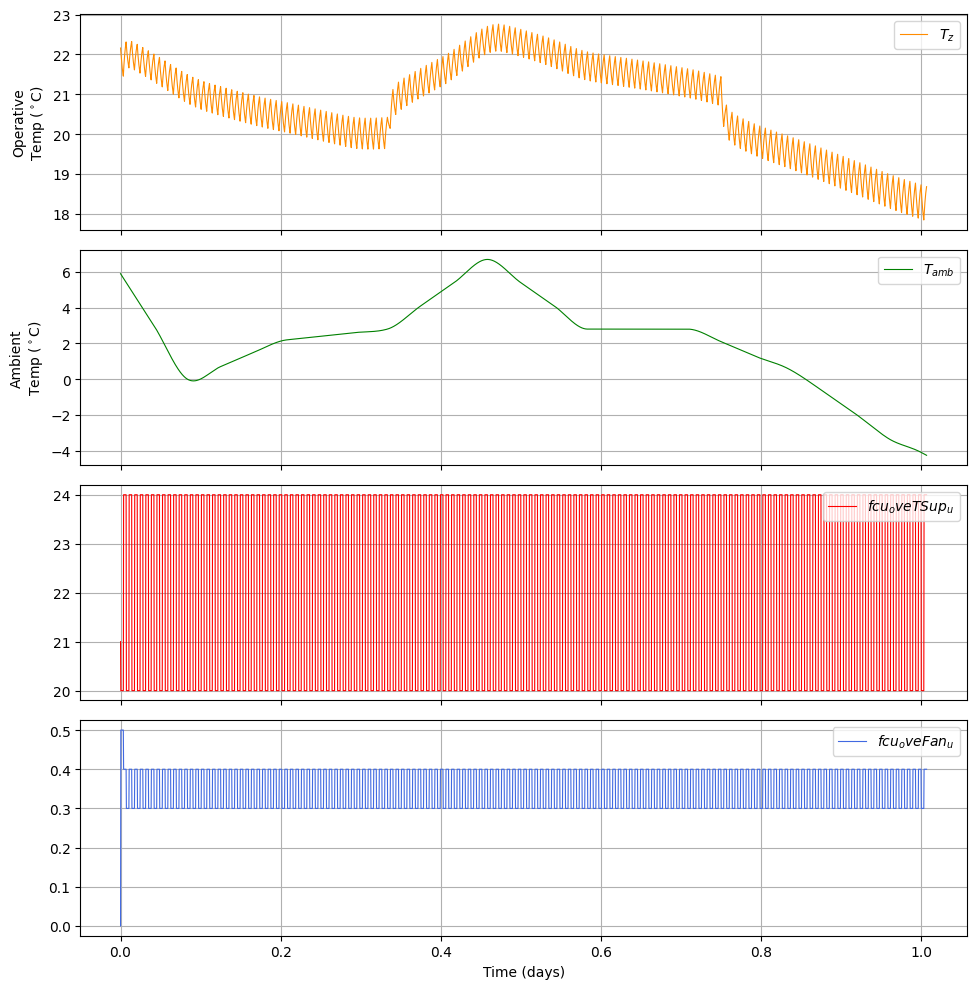

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.15,0.0,279.050000,0.000000
3801630,295.222125,293.15,0.5,279.025812,0.000347
3801660,295.117210,293.15,0.5,279.001625,0.000694
3801690,295.023884,293.15,0.5,278.977439,0.001042
3801720,294.940950,293.15,0.5,278.953254,0.001389
...,...,...,...,...,...
3888480,291.596497,297.15,0.4,268.916667,1.005556
3888510,291.665618,297.15,0.4,268.908333,1.005903
3888540,291.727400,297.15,0.4,268.900000,1.006250


In [9]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    

    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

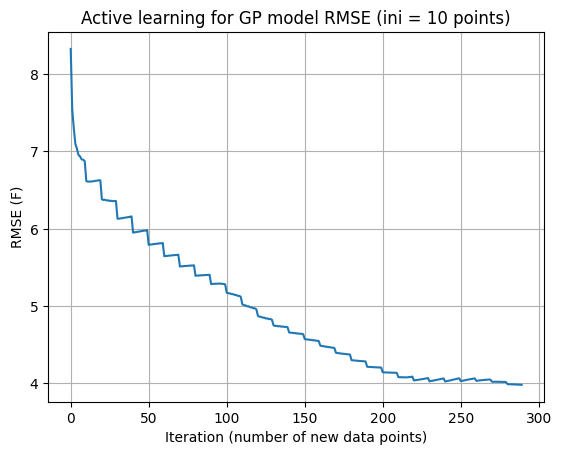

In [10]:
ls_rmse = [r.cpu()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title('Active learning for GP model RMSE (ini = 10 points)')
plt.show()

In [ ]:
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_SE_GP"])

save_path = f"RMSE_SE_GP_ini{Ne_tr}_{const.ramp}.csv"                   
full_path = os.path.join(save_dir, save_path)               
df.to_csv(full_path, index=False)     

: 